In [1]:
import os
import cv2
import ast
import numpy as np
from tqdm import tqdm
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.optim import lr_scheduler

import pytorch_lightning as pl
import segmentation_models_pytorch as smp

In [3]:
MODEL_NAME = "deeplabv3plus" # Available options are: ['unet', 'unetplusplus', 'manet', 'linknet', 'fpn', 'pspnet', 'deeplabv3', 'deeplabv3plus', 'pan', 'upernet', 'segformer', 'dpt']"
ENCODER_NAME = "resnext50_32x4d" 
DEVICE_ID = 2
EPOCHS = 100
LEARNING_RATE = 3e-4
BATCH_SIZE = 128
IMAGE_SIZE = 320
SEED = 42

In [4]:
DATA_DIR = r'/home/c/choton/beemachine/datasets/Others/fish-vista' # Define the Fish-Vista dataset directory

# Load the segmentation splits and check the shape
seg_train_csv = os.path.join(DATA_DIR, r'segmentation_train.csv')
seg_train_aug_csv = os.path.join(DATA_DIR, r'segmentation_train_aug.csv')
seg_val_csv = os.path.join(DATA_DIR, r'segmentation_val.csv')
seg_test_csv = os.path.join(DATA_DIR, r'segmentation_test.csv')
seg_train_df = pd.read_csv(seg_train_csv)
seg_train_aug_df = pd.read_csv(seg_train_aug_csv)
seg_val_df = pd.read_csv(seg_val_csv)
seg_test_df = pd.read_csv(seg_test_csv)
print(f'Shape of FishVista segmentation datasets,  train: {seg_train_df.shape}, train_aug: {seg_train_aug_df.shape}, validation: {seg_val_df.shape}, test): {seg_test_df.shape}')
print(f'Columns of the test dataset:', list(seg_test_df.columns))

# Class labels of the segmentation split
train_species = set(list(seg_train_df['standardized_species']))
val_species = set(list(seg_val_df['standardized_species']))
test_species = set(list(seg_test_df['standardized_species']))
check_val = [v for v in val_species if v not in train_species]
check_test = [v for v in test_species if v not in train_species]
print(f'The number of classes (species) are, train: {len(train_species)}, val: {len(val_species)}, test: {len(test_species)}')
print(f'Species in val but not train: {len(check_val)},  species in test but not train: {len(check_test)}')

# Read the mask labels (traits)
seg_json_path = os.path.join(DATA_DIR, 'segmentation_masks', 'seg_id_trait_map.json')
with open(seg_json_path, 'r') as json_file:
    content = json_file.read()
    seg_json = ast.literal_eval(content)
    print('Names of the mask labels (traits):')
    print(seg_json)
labels = list(seg_json.values())

Shape of FishVista segmentation datasets,  train: (4312, 11), train_aug: (25872, 3), validation: (316, 11), test): (1504, 11)
Columns of the test dataset: ['index', 'filename', 'source_filename', 'original_format', 'arkid', 'source', 'owner', 'license', 'original_url', 'family', 'standardized_species']
The number of classes (species) are, train: 2586, val: 303, test: 1224
Species in val but not train: 146,  species in test but not train: 639
Names of the mask labels (traits):
{0: 'Background', 1: 'Head', 2: 'Eye', 3: 'Dorsal fin', 4: 'Pectoral fin', 5: 'Pelvic fin', 6: 'Anal fin', 7: 'Caudal fin', 8: 'Adipose fin', 9: 'Barbel'}


In [5]:
def visualize(*, labels=None, **images):
    """Plot images + masks in one row with perfect discrete colormap legend (unlimited classes)"""
    n = len(images)
    plt.figure(figsize=(4 + 4 * n, 6))  # auto-scale width
    for i, (name, data) in enumerate(images.items(), 1):
        plt.subplot(1, n, i)
        plt.xticks([]); plt.yticks([])
        plt.title(name.replace("_", " ").title(), fontsize=14)
        arr = np.asarray(data)

        # ---------------- IMAGE ----------------
        if name == "image":
            # Handle CHW → HWC
            if arr.ndim == 3 and arr.shape[0] == 3:
                arr = arr.transpose(1, 2, 0)
            # Normalize to 0–1 if needed
            if arr.max() > 1.0:
                arr = arr / 255.0
            plt.imshow(arr)
            continue

        # ---------------- MASK PLOTTING ----------------
        # Supports unlimited integer classes with exact color mapping
        mask = arr.squeeze()  # H x W
        cmap = plt.get_cmap("turbo")  # # Alternatives: "nipy_spectral", "hsv", "jet", "gist_ncar"        
        bounds = np.arange(-0.5, mask.max() + 1.5, 1)
        norm = BoundaryNorm(bounds, cmap.N)
        plt.imshow(mask, cmap=cmap, norm=norm, interpolation="nearest")

        # ---------------- LEGEND ----------------
        # Exact color match between image and legend
        handles = [
            Patch(
                color=cmap(norm(v)),  # exact color used in the image
                label=labels[v] if v < len(labels) else f"Class {v} (unknown)"
            )
            for v in np.unique(mask)
        ]

        plt.legend(
            handles=handles, title="Classes", bbox_to_anchor=(1.05, 1),
            loc="upper left", borderaxespad=0.0, fontsize=10, title_fontsize=12
        )

    plt.tight_layout()
    plt.show()

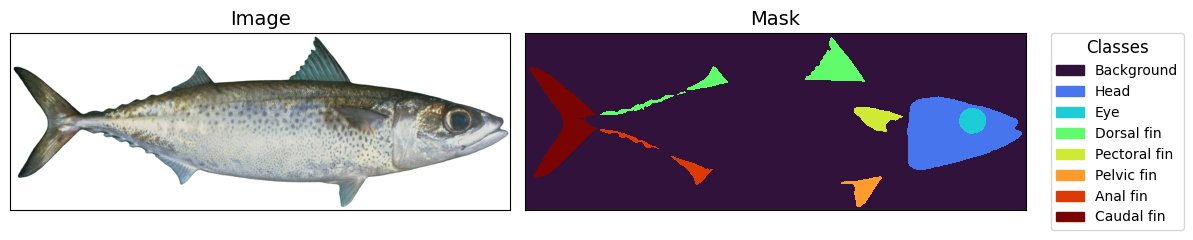

In [6]:
# Original image and mask
sample_img = seg_train_df['filename'][30]
sample_img_path = os.path.join(DATA_DIR, 'Images', sample_img)
sample_img_obj = Image.open(sample_img_path)
sample_mask_path = os.path.join(DATA_DIR, 'segmentation_masks', 'images', sample_img)[:-4]+'.png'
sample_mask_obj = Image.open(sample_mask_path)
visualize(labels=labels, image=sample_img_obj, mask=sample_mask_obj)

In [10]:
# Original image and mask
sample_img = seg_train_aug_df['filename'][30]
sample_img

'15344259938736cvriy1mZHZWJq2v#2.jpg_orig.jpg'

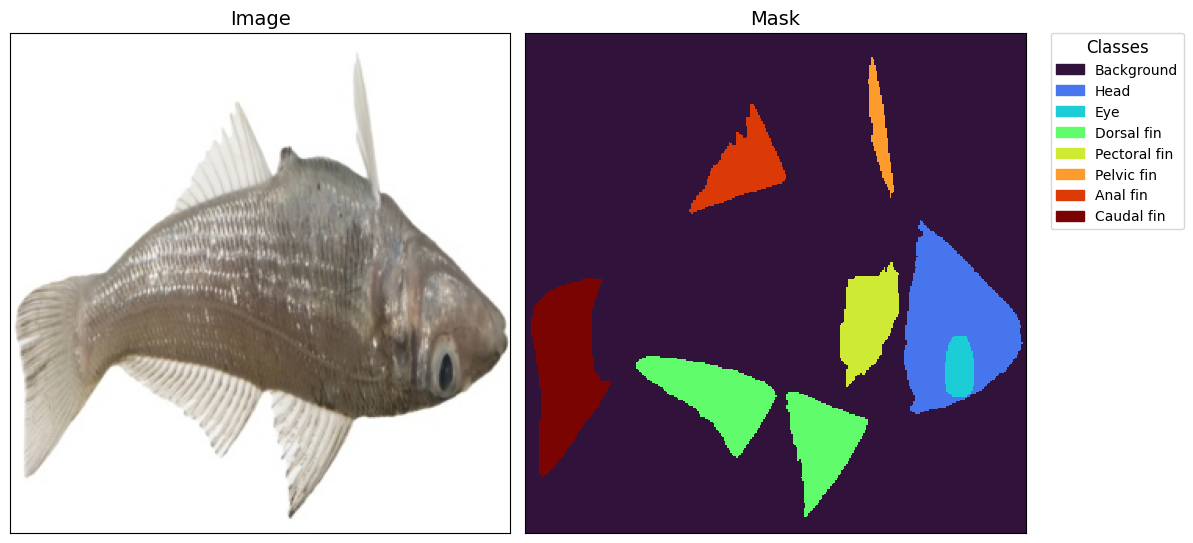

In [12]:
# Original image and mask
sample_img = seg_train_aug_df['filename'][440]
sample_img_path = os.path.join(DATA_DIR, 'train_aug_images', sample_img)
sample_img_obj = Image.open(sample_img_path)
sample_mask_path = os.path.join(DATA_DIR, 'train_aug_masks', sample_img)[:-4]+'_m.png'
sample_mask_obj = Image.open(sample_mask_path)
visualize(labels=labels, image=sample_img_obj, mask=sample_mask_obj)

In [18]:
class PartWholeDataset(Dataset):
    def __init__(self, image_dir, mask_dir, df=None, image_size=224, mask_sfx='.png', data_path=DATA_DIR):
        self.df = df
        self.mask_sfx = mask_sfx # Mask suffix "_m.png"
        self.image_size = image_size
        self.image_dir = image_dir # os.path.join(data_path, 'Images')
        self.mask_dir = mask_dir # os.path.join(data_path, 'segmentation_masks', 'images')
        self.image_names = list(self.df['filename']) # os.listdir(self.image_dir)
        # self.image_paths = [os.path.join(self.image_dir, p) for p in self.image_names]

        # transform for image
        self.img_transform = transforms.Compose([
            transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
        ])
        self.mask_transform = transforms.Compose([
            transforms.Resize(
                (image_size, image_size),
                interpolation=transforms.InterpolationMode.NEAREST
            ),
            transforms.PILToTensor(),  # keeps integer values
        ])
    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        # Load the image at index idx and convert to tensor
        img_name = self.image_names[idx]
        img_path = os.path.join(self.image_dir, img_name)
        img_pil = Image.open(img_path)
        img_tens = self.img_transform(img_pil)

        # Load the corresponding mask and convert to tensor
        mask_path = os.path.join(self.mask_dir, img_name)[:-4]+self.mask_sfx
        mask_pil = Image.open(mask_path)
        mask_tens = self.mask_transform(mask_pil)

        cls_label = self.df['standardized_species'][idx]
        return img_tens, mask_tens.squeeze(0), cls_label

In [19]:
imgs_path = os.path.join(DATA_DIR, 'Images')
masks_path = os.path.join(DATA_DIR, 'segmentation_masks', 'images')
aug_imgs_path = os.path.join(DATA_DIR, 'train_aug_images')
aug_masks_path = os.path.join(DATA_DIR, 'train_aug_masks')

train_dataset = PartWholeDataset(image_dir=imgs_path, mask_dir=masks_path, df=seg_train_df, image_size=IMAGE_SIZE)
train_aug_dataset = PartWholeDataset(image_dir=aug_imgs_path, mask_dir=aug_masks_path, df=seg_train_aug_df, image_size=IMAGE_SIZE, mask_sfx='_m.png')
val_dataset = PartWholeDataset(image_dir=imgs_path, mask_dir=masks_path, df=seg_val_df, image_size=IMAGE_SIZE)
test_dataset = PartWholeDataset(image_dir=imgs_path, mask_dir=masks_path, df=seg_test_df, image_size=IMAGE_SIZE)

print(f"Train: {len(train_dataset)}, Train_aug: {len(train_aug_dataset)},  Val: {len(val_dataset)}, Test: {len(test_dataset)}")
num_classes = len(labels)
print(f"Training with number of part labels (including background) = {num_classes}")
print("Part labels:", labels)

Train: 4312, Train_aug: 25872,  Val: 316, Test: 1504
Training with number of part labels (including background) = 10
Part labels: ['Background', 'Head', 'Eye', 'Dorsal fin', 'Pectoral fin', 'Pelvic fin', 'Anal fin', 'Caudal fin', 'Adipose fin', 'Barbel']


class_id: pristolepis fasciata


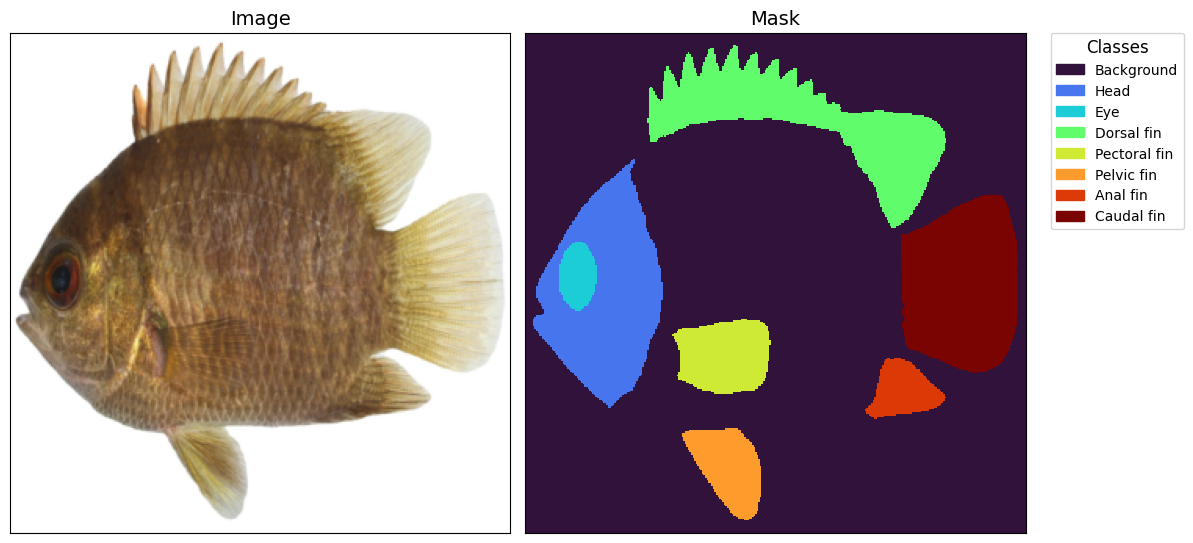

In [21]:
# Get sample image and mask
img, mask, class_id = train_dataset[60]
print(f"class_id: {class_id}")
visualize(labels=labels, image=img, mask=mask)

class_id: triportheus angulatus


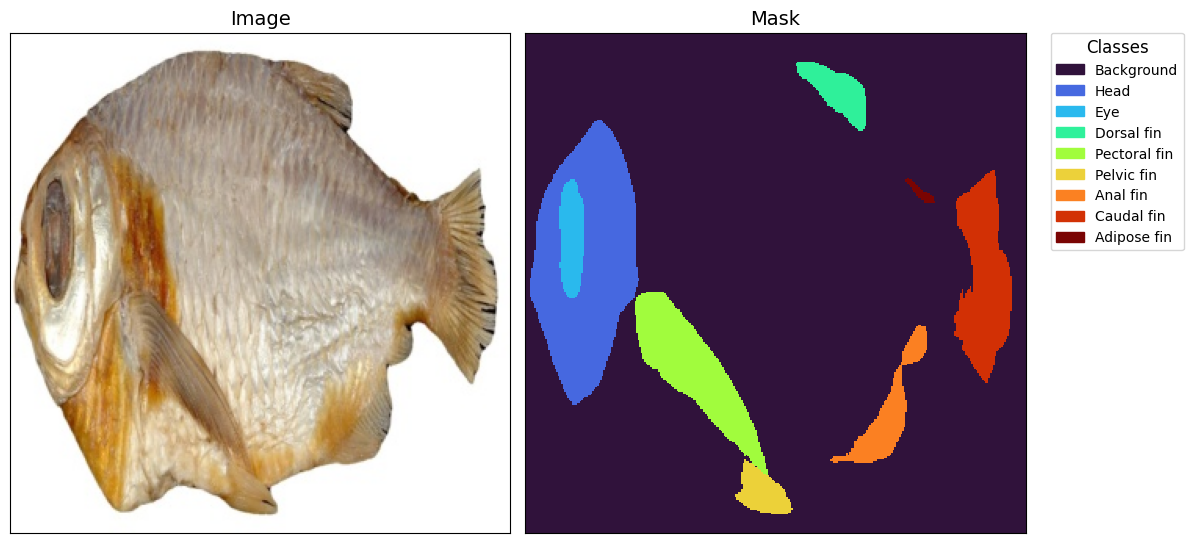

In [23]:
# Get sample image and mask
img, mask, class_id = train_aug_dataset[0]
print(f"class_id: {class_id}")
visualize(labels=labels, image=img, mask=mask)

class_id: triportheus angulatus


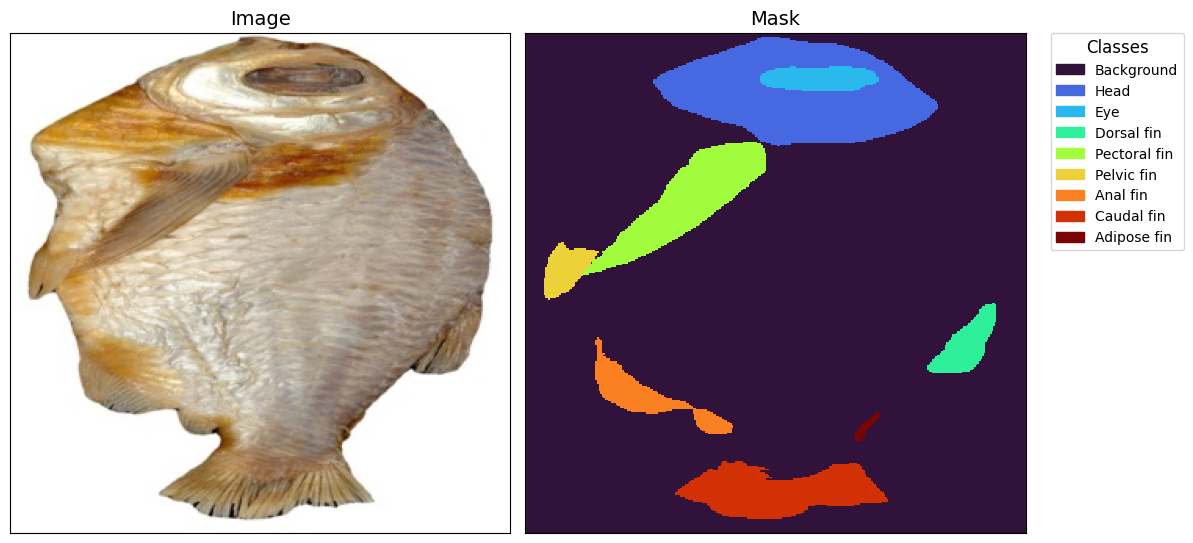

In [24]:
# Get sample image and mask
img, mask, class_id = train_aug_dataset[1]
print(f"class_id: {class_id}")
visualize(labels=labels, image=img, mask=mask)

class_id: triportheus angulatus


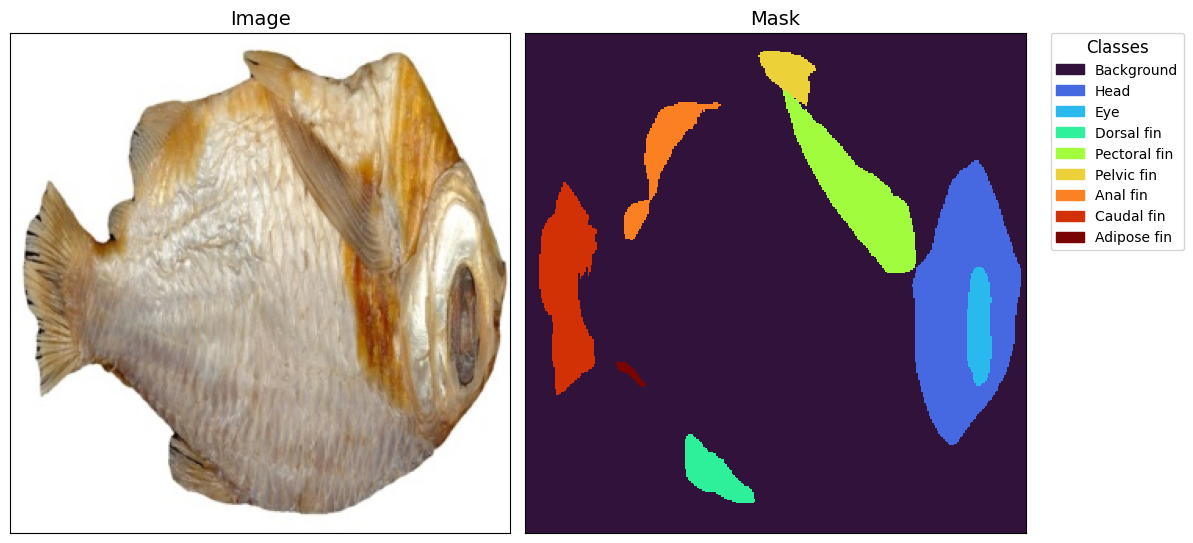

In [25]:
# Get sample image and mask
img, mask, class_id = train_aug_dataset[2]
print(f"class_id: {class_id}")
visualize(labels=labels, image=img, mask=mask)

class_id: triportheus angulatus


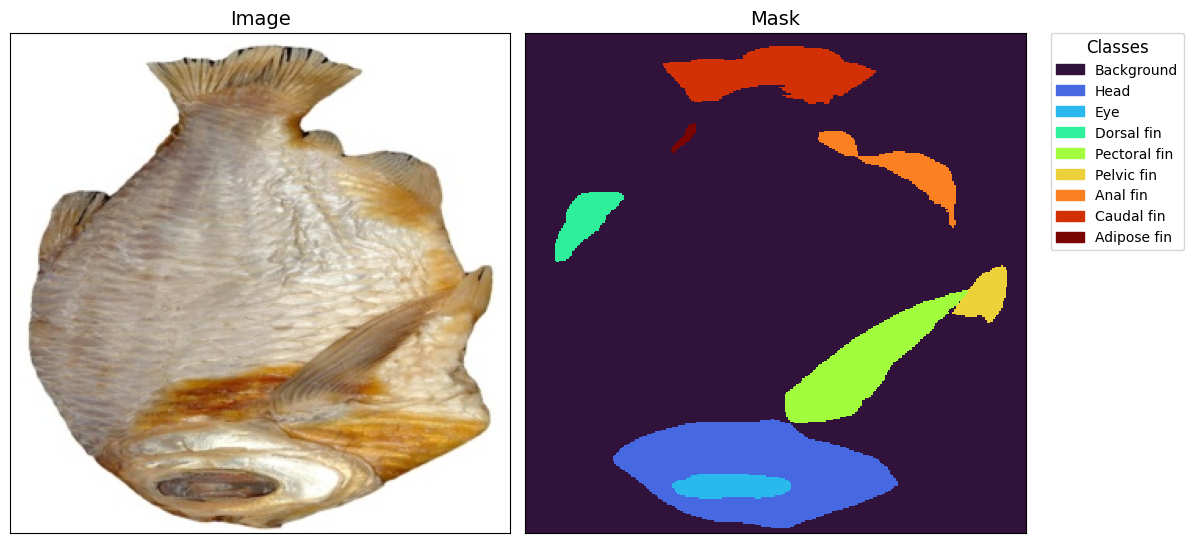

In [26]:
# Get sample image and mask
img, mask, class_id = train_aug_dataset[3]
print(f"class_id: {class_id}")
visualize(labels=labels, image=img, mask=mask)